In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Plotting $\hat{m}_{i \to j}(n_i)$

In [2]:
path = "/media/david/Data/UH/Grupo_de_investigacion/Ecology/Results/PBMF/AllData/Printall/nsamples_10"
T = 0.50
lda = 0.01
av0 = "0.90"
tol = "1.0e-04"
maxiter = "1000"
nmin = 0.001
nmin_str = "1.0e-03"
nmax = 5.00
npoints = 500
N = 512
c = 3

dn = (nmax - nmin) / npoints
nvals = np.arange(nmin, nmax, dn)

In [3]:
def read_mhat(filename, N):
    """
    Read a file with the messages and return a numpy array with the messages and a nx graph
    """
    with open(filename, 'r') as f:
        lines = f.readlines()

    graph = nx.empty_graph(N, create_using=nx.DiGraph)
    messages = []
    for line in lines:
        parts = line.split()
        index = int(parts[0])
        i, j = (int(x) for x in parts[1][5:].split("to"))
        message = [float(x) for x in parts[2:]]
        messages.append(message)
        graph.add_edge(i, j, index_message=index)

    messages = np.array(messages)
    return messages, graph

In [4]:
def plot_mhat(messages, graph, sel_edges, nvals):
    plt.rcParams['text.usetex'] = True
    for i, j in sel_edges:
        index = graph[i][j]['index_message']
        str_itoj = str(i) + '\to' + str(j)
        plt.plot(nvals, messages[index], label=r'$\hat{m}_{' + str_itoj + '}(n)$')
    plt.xlabel("n")
    plt.ylabel(r"$\hat{m}_{i\to j}(n_i)$")
    plt.show()

In [5]:
eps_plot = 1.00
mu_plot = 0.10
sigma_plot = 0.28
seed_plot = 1

filename = f'PBMF_Lotka_Volterra_steady_state_messhat_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_eps_{"{0:.2f}".format(eps_plot)}_mu_{"{0:.2f}".format(mu_plot)}_sigma_{"{0:.2f}".format(sigma_plot)}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}_seed_{seed_plot}.txt'
full_name = path + '/' + filename

In [6]:
messages, graph = read_mhat(full_name, N)

In [10]:
nsamples = 50
sel_edges = []
for i in range(nsamples):
    e = np.random.randint(0, graph.number_of_edges())
    sel_edges.append(list(graph.edges)[e])
print(sel_edges)

[(230, 131), (199, 303), (415, 298), (96, 253), (93, 2), (52, 368), (98, 1), (30, 123), (434, 465), (52, 25), (12, 438), (331, 419), (92, 121), (467, 397), (79, 304), (17, 469), (289, 182), (57, 385), (42, 83), (221, 410), (35, 37), (46, 29), (353, 20), (116, 159), (191, 24), (79, 304), (442, 60), (415, 71), (13, 28), (320, 490), (295, 97), (12, 203), (429, 160), (78, 247), (172, 148), (246, 462), (344, 128), (53, 165), (489, 74), (330, 200), (30, 123), (267, 460), (511, 464), (5, 323), (53, 336), (220, 338), (295, 417), (192, 485), (134, 7), (28, 13)]


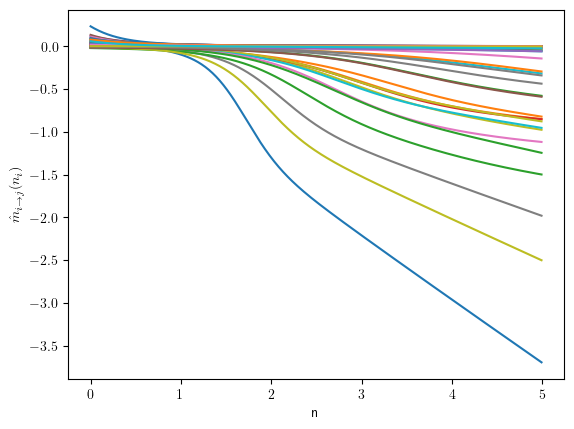

In [11]:
plot_mhat(messages, graph, sel_edges, nvals)

# Plotting $P(n_i)$

In [7]:
def read_psingle(filename):
    fin = open(filename, 'r')
    lines = fin.readlines()
    p_single = []
    for line in lines:
        parts = line.split()
        p_single.append([float(x) for x in parts[1:]])
    fin.close()
    return np.array(p_single)

In [8]:
def plot_psingle(p_single, sel_nodes, nvals):
    plt.rcParams['text.usetex'] = True
    for i in sel_nodes:
        plt.plot(nvals, p_single[i], label=r'$P_{' + str(i) + '}(n)$')
    plt.yscale('log')
    plt.xlabel("n")
    plt.ylabel(r"$P_i(n)$")
    plt.show()

In [9]:
filename_psingle = f'PBMF_Lotka_Volterra_steady_state_psingle_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_eps_{"{0:.2f}".format(eps_plot)}_mu_{"{0:.2f}".format(mu_plot)}_sigma_{"{0:.2f}".format(sigma_plot)}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}_seed_{seed_plot}.txt'
full_name_psingle = path + '/' + filename_psingle

In [10]:
p_single = read_psingle(full_name_psingle)

In [14]:
nsamples_psingle = 50
sel_nodes = np.random.randint(0, N, nsamples_psingle)

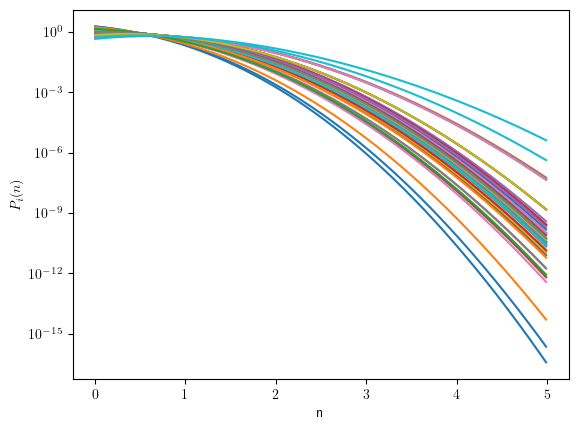

In [15]:
plot_psingle(p_single, sel_nodes, nvals)

# Plot average distribution $\hat{P}(n)$

In [11]:
def plot_av_dist_log(nvals, av_dist_list, labels, figname, eps, mu, sigma):
    plt.figure()
    for i in range(len(av_dist_list)):
        av_dist = av_dist_list[i]
        plt.plot(nvals, av_dist, label=labels[i])
    plt.xlabel('n')
    plt.ylabel(r'$\hat{P}(n)$')
    plt.yscale('log')
    plt.title(r'$\epsilon=$' + str(eps) + r'  $\mu=$' + str(mu) + r'  $\sigma=$' + str(sigma), fontsize=12)
    plt.legend(loc='best')
    plt.xlim(nvals[0], 2)
    plt.ylim(1e-2, 2)
    plt.savefig(figname)
    plt.close()

In [12]:
def build_params_from_sched(sched):
    params = []
    for eps in sched['eps']:
        for mu in sched['mu']:
            for sigma in sched['sigma']:
                params.append((eps, mu, sigma))
    return params

In [13]:
def plot_sched_final(nvals, sched, path_to_data, path_to_fig, T, lda, av0, tol, maxiter, N, c, seed0, seedf, nmin_str, nmax, npoints):
    params_list = build_params_from_sched(sched)
    for eps, mu, sigma in params_list:
        dist_list = []
        labels = []
        for seed in range(seed0, seedf + 1):
            filedata = f'PBMF_Lotka_Volterra_steady_state_psingle_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_eps_{"{0:.2f}".format(eps)}_mu_{"{0:.2f}".format(mu)}_sigma_{"{0:.2f}".format(sigma)}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}_seed_{seed}.txt'
            psingle = read_psingle(path_to_data + '/' + filedata)
            av_dist = np.mean(psingle, axis=0)
            dist_list.append(av_dist)
            labels.append(f'seed={seed}')
        figname = f'PBMF_Lotka_Volterra_av_dist_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_eps_{"{0:.2f}".format(eps)}_mu_{"{0:.2f}".format(mu)}_sigma_{"{0:.2f}".format(sigma)}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}.png' 
        figout = path_to_fig + "/" + figname
        plot_av_dist_log(nvals, dist_list, labels, figout, eps, mu, sigma)

In [14]:
path_to_data = '/media/david/Data/UH/Grupo_de_investigacion/Ecology/Results/PBMF/AllData/Printall/nsamples_10'
path_to_fig = '/media/david/Data/UH/Grupo_de_investigacion/Ecology/Results/PBMF/Distribution_Figures'

In [15]:
sched_1 = {"eps":[0.0], "mu":[0.0], "sigma":[0.30, 0.40, 0.45, 0.55]}
sched_2 = {"eps":[1.0], "mu":[0.0], "sigma":[0.05, 0.25, 0.33, 0.45]}
sched_3 = {"eps":[1.0], "mu":[0.1], "sigma":[0.05, 0.28, 0.40, 0.55]}
seed0 = 1
seedf = 10
scheds = [sched_1, sched_2, sched_3]

In [21]:
for sched in scheds:
    plot_sched_final(nvals, sched, path_to_data, path_to_fig, T, lda, av0, tol, maxiter, N, c, seed0, seedf, nmin_str, nmax, npoints)

# Identifying non-convergent cycles

In [16]:
def read_all_fields_hist(filename):
    fin = open(filename, "r")
    lines = fin.readlines()
    fin.close()

    avn_hist = []
    niters = []
    for line in lines[1:]:
        parts = line.split()
        niters.append(int(parts[0]))
        avn_hist.append([float(x) for x in parts[1:]])

    avn_hist = np.array(avn_hist)
    return niters, avn_hist

In [17]:
def read_graph(filename, N):
    """
    Read a file with the messages and return a numpy array with the messages and a nx graph
    """
    with open(filename, 'r') as f:
        lines = f.readlines()

    graph = nx.empty_graph(N, create_using=nx.DiGraph)
    for line in lines:
        parts = line.split()
        index = int(parts[0])
        i, j = (int(x) for x in parts[1][5:].split("to"))
        graph.add_edge(i, j, index_message=index)

    return graph

In [18]:
def identify(avn_hist, tol_var=1e-3):
    nit, N = avn_hist.shape
    vars = np.zeros((nit - 1, N))
    for i in range(nit - 1):
        vars[i, :] = avn_hist[i + 1, :] - avn_hist[i, :]
    streaks = np.zeros(N, dtype=int)
    converged = []
    bistable = []
    noisy = []
    for i in range(N):
        if np.abs(vars[-1, i]) < tol_var and np.abs(vars[-2, i]) < tol_var:
            converged.append(i)
            cond = True
            while cond and streaks[i] < nit - 1:
                if np.abs(vars[-1 - streaks[i], i]) < tol_var:
                    streaks[i] += 1
                else:
                    cond = False
        elif vars[-1, i] * vars[-2, i] < 0 and np.abs(vars[-1, i] + vars[-2, i]) < tol_var:
            bistable.append(i)
            cond = True
            while cond and streaks[i] < nit - 2:
                if vars[-1 - streaks[i], i] * vars[-2 - streaks[i], i] < 0 and np.abs(vars[-1 - streaks[i], i] + vars[-2 - streaks[i], i]) < tol_var:
                    streaks[i] += 1
                else:
                    cond = False
        else:
            noisy.append(i)
    return converged, bistable, noisy, streaks

In [19]:
def identify_all(scheds, path_to_data, path_to_out, T, lda, av0, tol, maxiter, N, c, seed0, seedf, nmin_str, nmax, npoints):
    fileout = path_to_out + "/" + f'PBMF_LV_identify_conv_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}.txt'
    filestreak = path_to_out + "/" + f'PBMF_LV_streaks_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}.txt'
    fo = open(fileout, "w")
    fs = open(filestreak, "w")
    fo.write("# eps mu sigma seed N converged bistable noisy\n")
    fs.write("# eps mu sigma seed N streaks\n")
    all_converged = {}
    all_bistable = {}
    all_noisy = {}
    params_processed = []
    for sched in scheds:
        params_list = build_params_from_sched(sched)
        for eps, mu, sigma in params_list:
            for seed in range(seed0, seedf + 1):
                filedata = f'PBMF_Lotka_Volterra_field_hist_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_eps_{"{0:.2f}".format(eps)}_mu_{"{0:.2f}".format(mu)}_sigma_{"{0:.2f}".format(sigma)}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}_print_every_{seed}_seed_1.txt'
            
                _, fields_hist = read_all_fields_hist(path_to_data + "/" + filedata)
                if fields_hist.shape[0] > 2:
                    params_processed.append((eps, mu, sigma, seed))
                    converged, bistable, noisy, streaks = identify(fields_hist)
                    fo.write(f'{eps} {mu} {sigma} {seed} {len(streaks)} {len(converged)} {len(bistable)} {len(noisy)}\n')
                    all_converged[(eps, mu, sigma, seed)] = converged
                    all_bistable[(eps, mu, sigma, seed)] = bistable
                    all_noisy[(eps, mu, sigma, seed)] = noisy
                    fs.write(f'{eps} {mu} {sigma} {seed} {len(streaks)}')
                    for i in range(len(streaks)):
                        fs.write(f' {streaks[i]}')
                    fs.write('\n')
                else:
                    all_converged[(eps, mu, sigma, seed)] = []
                    all_bistable[(eps, mu, sigma, seed)] = []
                    all_noisy[(eps, mu, sigma, seed)] = []

    fo.close()
    fs.close()
    return params_processed, all_converged, all_bistable, all_noisy

In [20]:
def plot_in_graph(graph, bistable, noisy, figname, eps, mu, sigma, seed):
    plt.figure()
    pos = nx.spring_layout(graph)
    subgraph_both = graph.subgraph(bistable + noisy)
    subgraph_bistable = graph.subgraph(bistable)
    subgraph_noisy = graph.subgraph(noisy)
    nx.draw(subgraph_both, pos=pos, node_size=50, node_color='gray', edge_color='purple', alpha=0.5)
    nx.draw(subgraph_bistable, pos=pos, node_size=50, node_color='blue', edge_color='blue', alpha=0.5)
    nx.draw(subgraph_noisy, pos=pos, node_size=50, node_color='red', edge_color='red', alpha=0.5)
    plt.title(f'eps={eps} mu={mu} sigma={sigma} seed={seed}', fontsize=12)
    plt.savefig(figname)
    plt.close()

In [21]:
def plot_nonconvergent_in_graphs(params_processed, all_bistable, all_noisy, path_to_graph, path_to_plots, T, lda, av0, tol, maxiter, N, c, seed0, seedf, nmin_str, nmax, npoints):
    for eps, mu, sigma, seed in params_processed:
        if len(all_bistable[(eps, mu, sigma, seed)]) + len(all_noisy[(eps, mu, sigma, seed)]) > 0:
            filemess = f'PBMF_Lotka_Volterra_steady_state_messhat_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_eps_{"{0:.2f}".format(eps)}_mu_{"{0:.2f}".format(mu)}_sigma_{"{0:.2f}".format(sigma)}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}_seed_{seed}.txt'
            graph = read_graph(path_to_graph + "/" + filemess, N)
            figname = path_to_plots + "/" + f'PBMF_LV_plotingraph_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_eps_{"{0:.2f}".format(eps)}_mu_{"{0:.2f}".format(mu)}_sigma_{"{0:.2f}".format(sigma)}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}_seed_{seed}.png'
            plot_in_graph(graph, all_bistable[(eps, mu, sigma, seed)], all_noisy[(eps, mu, sigma, seed)], figname, eps, mu, sigma, seed)

In [22]:
def plot_bars(all_converged, all_bistable, all_noisy, path_to_out, T, lda, av0, tol, maxiter, eps, mu, sigma):
    figout = path_to_out + "/" + f'PBMF_LV_identify_conv_bars_gr_inside_RRG_T_{"{0:.2f}".format(T)}_lambda_{"{0:.2f}".format(lda)}_av0_{av0}_tol_{tol}_maxiter_{maxiter}_eps_{"{0:.2f}".format(eps)}_mu_{"{0:.2f}".format(mu)}_sigma_{"{0:.2f}".format(sigma)}_nmin_{nmin_str}_nmax_{"{0:.2f}".format(nmax)}_npoints_{npoints}_N_{N}_c_{c}.png'
    plt.figure()
    converged = all_converged[(eps, mu, sigma, seed0)]
    bistable = all_bistable[(eps, mu, sigma, seed0)]
    noisy = all_noisy[(eps, mu, sigma, seed0)]        
    plt.bar(seed0, len(converged), label=f'converged', color='green')
    plt.bar(seed0, len(bistable), bottom=len(converged), label=f'bistable', color='blue')
    plt.bar(seed0, len(noisy), bottom=len(converged) + len(bistable), label=f'noisy', color='red')
    for seed in range(seed0 + 1, seedf + 1):
        converged = all_converged[(eps, mu, sigma, seed)]
        bistable = all_bistable[(eps, mu, sigma, seed)]
        noisy = all_noisy[(eps, mu, sigma, seed)]        
        plt.bar(seed, len(converged), color='green')
        plt.bar(seed, len(bistable), bottom=len(converged), color='blue')
        plt.bar(seed, len(noisy), bottom=len(converged) + len(bistable), color='red')
        
    plt.xlabel('seed')
    plt.ylabel('Number of nodes')
    plt.title('PBMF    ' + r'$\epsilon=$' + str(eps) + r'  $\mu=$' + str(mu) + r'  $\sigma=$' + str(sigma), fontsize=12)
    plt.legend(loc='best')
    plt.savefig(figout)

In [23]:
path_to_graph = '/media/david/Data/UH/Grupo_de_investigacion/Ecology/Results/PBMF/AllData/Printall/nsamples_10'
path_to_out = '/media/david/Data/UH/Grupo_de_investigacion/Ecology/Results/PBMF/Identifying_Convergence'
path_to_plots = '/media/david/Data/UH/Grupo_de_investigacion/Ecology/Results/PBMF/Identifying_Convergence'

In [24]:
params_processed, all_converged, all_bistable, all_noisy = identify_all(scheds, path_to_data, path_to_out, T, lda, av0, tol, maxiter, N, c, seed0, seedf, nmin_str, nmax, npoints)

In [31]:
plot_nonconvergent_in_graphs(params_processed, all_bistable, all_noisy, path_to_graph, path_to_plots, T, lda, av0, tol, maxiter, N, c, seed0, seedf, nmin_str, nmax, npoints)

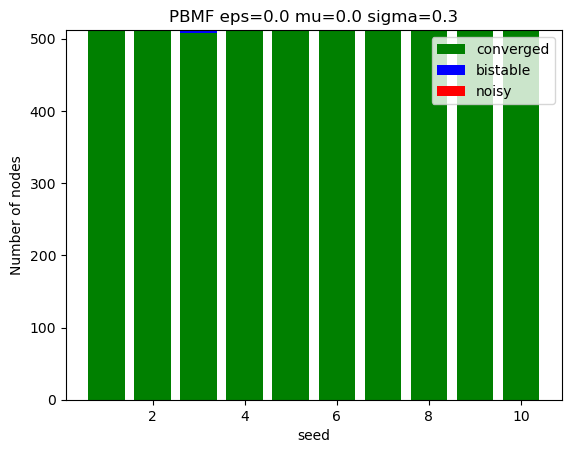

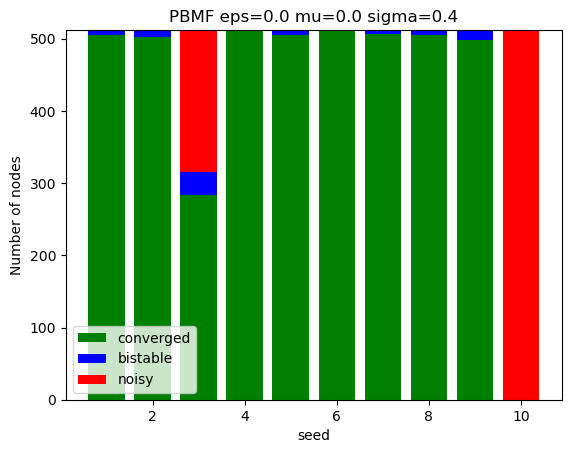

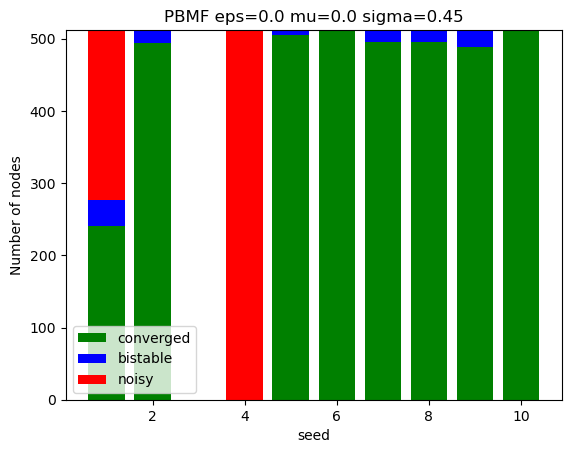

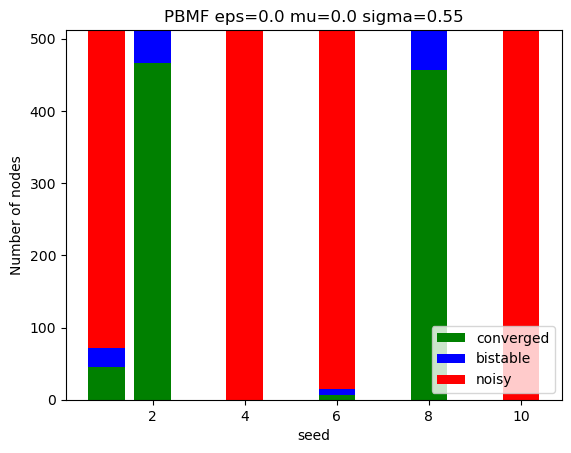

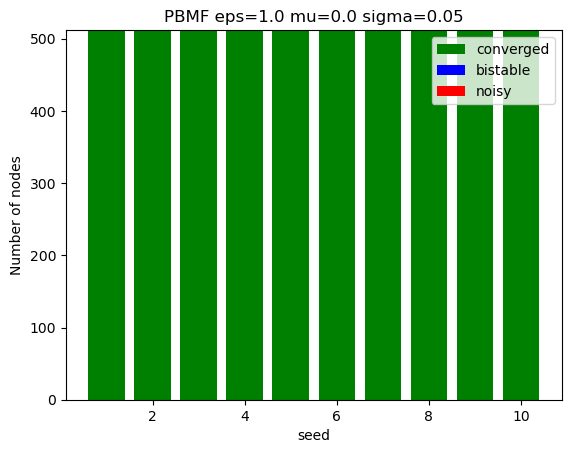

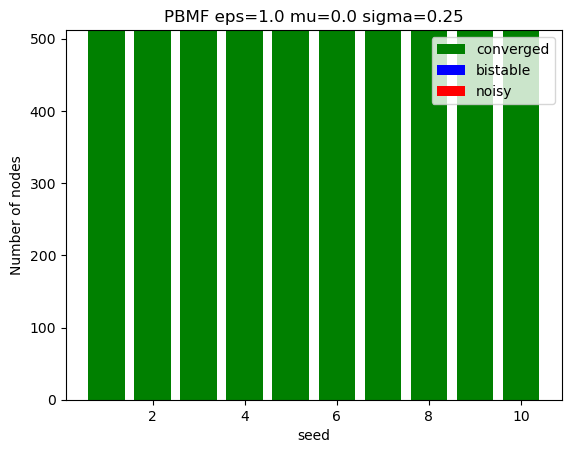

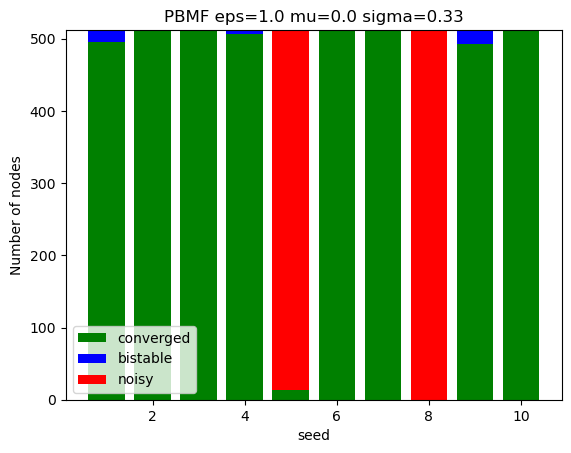

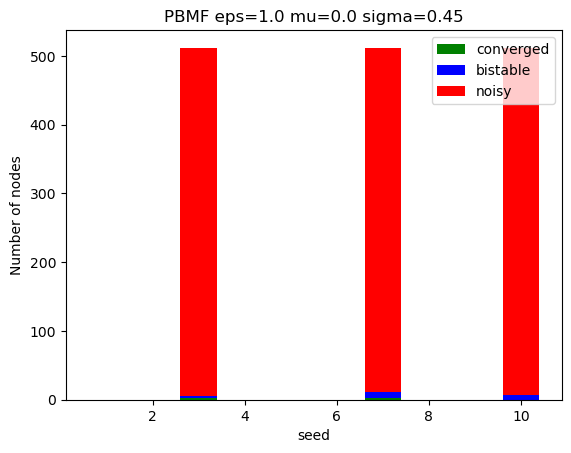

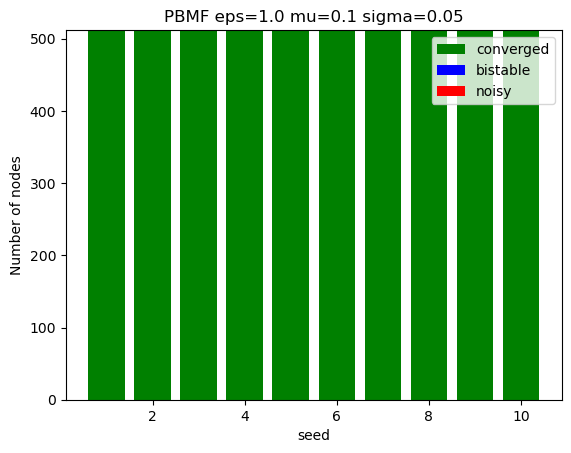

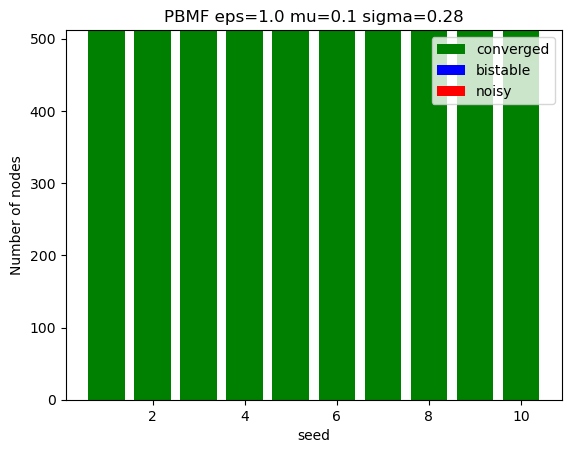

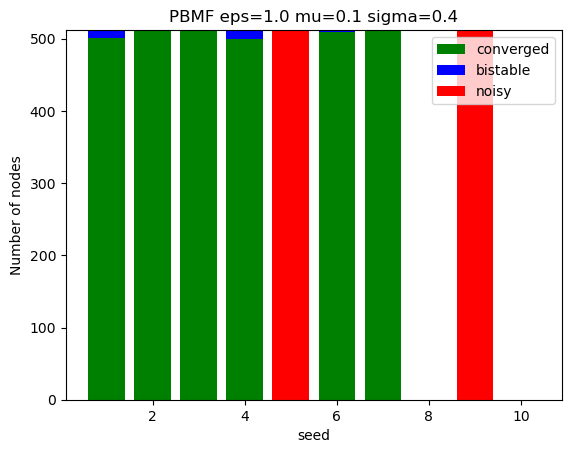

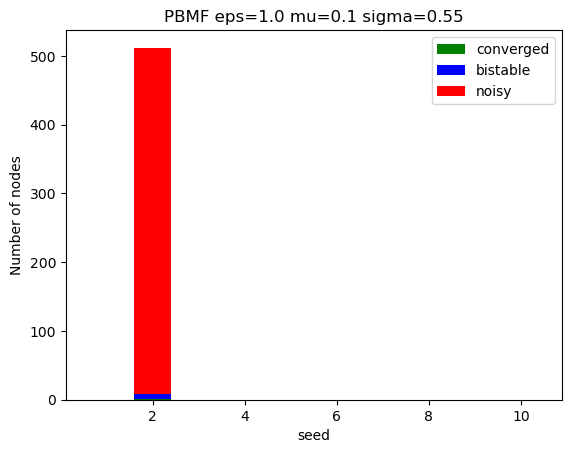

In [25]:
for sched in scheds:
        params_list = build_params_from_sched(sched)
        for eps, mu, sigma in params_list:
            plot_bars(all_converged, all_bistable, all_noisy, path_to_out, T, lda, av0, tol, maxiter, eps, mu, sigma)